# 01 — Quickstart: temperature → heat flux in a few lines

`icarus` predicts local heat flux from infrared temperature fields using reduced-order (POD) modal features and a neural network.

```
pip install icarus-thermal
```

This notebook is fully self-contained: it generates a synthetic boiling-like dataset, so you can run it without any experimental data. With your own data, replace the synthetic block with
`data = tf.load("experiment.mat", temperature_key="T", heatflux_key="qL2")`.

In [1]:
import icarus as tf
print('icarus', tf.__version__)

icarus 0.6.0


## 1. Make (or load) a dataset

Fields are `[ny, nx, nt]` — two spatial dimensions and time.

In [2]:
import numpy as np

def make_boiling_like_data(ny=24, nx=30, nt=1500, dt=1e-3, seed=0):
    """Synthetic dataset that mimics a boiling IR recording:
    a slow large-scale mode + a localized 'nucleation site' pulsing at 40 Hz,
    with heat flux linearly coupled to temperature + irreducible noise."""
    rng = np.random.default_rng(seed)
    yy, xx = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, ny))
    t = np.arange(nt) * dt

    slow_pattern = np.sin(np.pi * yy) * np.cos(np.pi * xx)
    slow = slow_pattern[:, :, None] * np.sin(2 * np.pi * 5 * t)

    site = np.exp(-(((yy - 0.7) ** 2 + (xx - 0.6) ** 2) / 0.01))
    site_pulse = site[:, :, None] * np.sin(2 * np.pi * 40 * t)

    T = 420.0 + 3.0 * slow + 1.5 * site_pulse         + 0.05 * rng.standard_normal((ny, nx, nt))
    q = 3.0e5 - 1.2e4 * (3.0 * slow) + 0.9e4 * (1.5 * site_pulse)         + 2.0e3 * rng.standard_normal((ny, nx, nt))
    return T, q, dt

T, q, dt = make_boiling_like_data()
print("T", T.shape, "| q", q.shape, "| dt", dt, "s")


T (24, 30, 1500) | q (24, 30, 1500) | dt 0.001 s


## 2. Fit the Model C pipeline

POD compresses each field into a few dominant spatial modes; an MLP learns the mapping from temperature modes to heat-flux modes.

In [3]:
from icarus.data.loader import from_arrays

data = from_arrays(T, q, dt=dt)
pipe = tf.Pipeline(strategy="modal", n_pod_modes=4, spatial_crop=2,
                   optimise_hyperparams=False)
pipe.model_ = tf.HeatFluxNet(strategy="modal", hidden_layer_sizes=(64,),
                             max_iter=300)
pipe.fit(data, verbose=False)
metrics = pipe.evaluate()

[train]  R² = 0.9746  RMSE = 2,015 W/m²  MAE = 1,608 W/m²
[test]  R² = 0.9748  RMSE = 2,011 W/m²  MAE = 1,604 W/m²


## 3. Predict on new temperature data

`predict` takes a raw temperature field and returns the reconstructed heat-flux field.

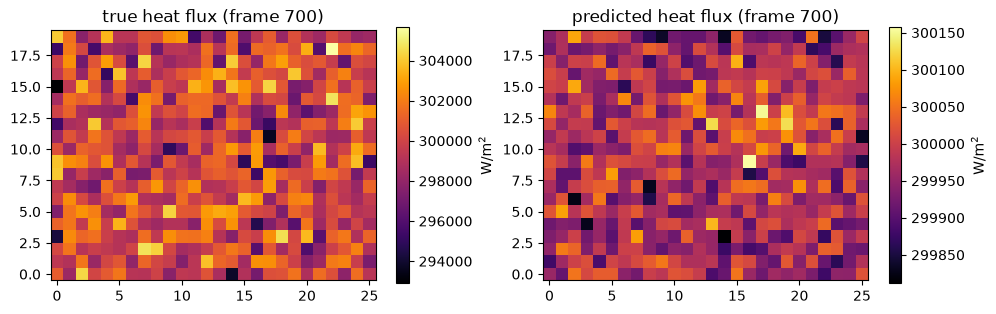

In [4]:
import matplotlib.pyplot as plt

T_proc = pipe._processed["T"]          # preprocessed field
q_true = pipe._processed["q"]
q_pred = pipe.predict(T_proc)

frame = 700
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (f, title) in zip(axes, [(q_true, "true heat flux"),
                                 (q_pred, "predicted heat flux")]):
    im = ax.imshow(f[:, :, frame], cmap="inferno", origin="lower")
    ax.set_title(f"{title} (frame {frame})")
    fig.colorbar(im, ax=ax, shrink=0.8, label="W/m$^2$")
plt.tight_layout()

That's the core workflow: **load → fit → evaluate → predict**.

Next: [02 — Spectral POD](02_spectral_pod.ipynb) shows how to separate boiling structures by timescale.